<a href="https://colab.research.google.com/github/Kashaf537/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kashaf537/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Libraries to install

In [2]:
%pip install -q -U duckdb huggingface_hub pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.2/793.2 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 107.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.


In [ ]:
from huggingface_hub import login

login()

In [3]:
from huggingface_hub import whoami

info = whoami()
print("Authenticated as:", info["name"])

Authenticated as: Kashaf23


In [4]:
from huggingface_hub import list_datasets

datasets = list(list_datasets(search="flyrank", limit=20))

for ds in datasets:
    print(ds.id)

FlyRank/internship-warehouse
FlyRank/internship-starter
FlyRank/internship-lanes


In [5]:
from huggingface_hub import HfApi

api = HfApi()

files = api.list_repo_files(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset"
)

for f in files:
    print(f)

.gitattributes
README.md
dim_clients.parquet
dim_content.parquet
fact_content_daily_performance/month=2025-01/data_0.parquet
fact_content_daily_performance/month=2025-02/data_0.parquet
fact_content_daily_performance/month=2025-03/data_0.parquet
fact_content_daily_performance/month=2025-04/data_0.parquet
fact_content_daily_performance/month=2025-05/data_0.parquet
fact_content_daily_performance/month=2025-06/data_0.parquet
fact_content_daily_performance/month=2025-07/data_0.parquet
fact_content_daily_performance/month=2025-08/data_0.parquet
fact_content_daily_performance/month=2025-09/data_0.parquet
fact_content_daily_performance/month=2025-10/data_0.parquet
fact_content_daily_performance/month=2025-11/data_0.parquet
fact_content_daily_performance/month=2025-12/data_0.parquet
fact_content_daily_performance/month=2026-01/data_0.parquet
fact_content_daily_performance/month=2026-02/data_0.parquet
fact_content_daily_performance/month=2026-03/data_0.parquet
fact_content_daily_performance/mont

In [6]:
from huggingface_hub import get_token

hf_token = get_token()

print("Token available:", hf_token is not None)

Token available: True


In [7]:
import duckdb

con = duckdb.connect()

con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")

con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE HTTP,
        EXTRA_HTTP_HEADERS MAP {{
            'Authorization': 'Bearer {hf_token}'
        }}
    )
""")

print("DuckDB authenticated successfully.")

DuckDB authenticated successfully.


## 1. Question

*The research question and the decision it supports.*

Can historical search, content, and engagement signals be used to rank pages for proactive content-review prioritization, and does an ML model outperform a transparent baseline on unseen future data?

# Decision:

Which pages should a content team review first?

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

The capstone uses the FlyRank internship warehouse data.

The analysis focuses on content-level performance and historical search/engagement signals.

The main sources used are:

- `dim_content`
- `fact_content_daily_performance`
- `fact_content_query_90d`

The analysis uses anonymized identifiers only for grouping and joining. Client and content identifiers are never used as predictive features.

The performance data covers multiple monthly periods, allowing historical performance to be compared with a subsequent month.

### Exclusions

The following fields are excluded from model features:

- `client_hash_id` — used only for grouped validation.
- `content_hash_id` — used only to identify content.
- `trend_direction` — outcome-derived.
- `trend_pct` — outcome-derived and therefore leakage-prone.
- Future-period performance fields — used only to construct the target.
- Any client-identifying information, URLs, private queries, or credentials.

In [8]:
# ============================================================
# DATA — Load 90-day content/query performance
# ============================================================

query_url = (
    "hf://datasets/FlyRank/internship-warehouse/"
    "fact_content_query_90d.parquet"
)

query_df = con.execute(f"""
    SELECT *
    FROM read_parquet('{query_url}')
    LIMIT 10000
""").df()

print("Rows loaded:", len(query_df))
print("Columns:", len(query_df.columns))

display(query_df.head())

Rows loaded: 10000
Columns: 21


,client_hash_id,content_hash_id,query_hash_id,query_char_count,query_token_count,window_start,window_end,impressions_90d,clicks_90d,impressions_last30,...,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,avg_position_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_58b1b001f839d699,17,3,2026-04-02,2026-06-30,11,0,0,...,11,0,10.818182,NaN,10.818182,1466,14,32,0.043656,0.725102
1,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_922b8eca2a24cd34,34,7,2026-04-02,2026-06-30,13,0,0,...,1,0,1.769231,NaN,11.000000,1466,14,32,0.043656,0.725102
2,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_9f0c36a6ae2a6a99,16,2,2026-04-02,2026-06-30,16,0,11,...,5,0,23.562500,24.272727,22.000000,1466,14,32,0.043656,0.725102
3,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_a032820b5467e996,24,4,2026-04-02,2026-06-30,55,0,1,...,1,0,2.200000,13.000000,0.000000,1466,14,32,0.043656,0.725102
4,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_ba1a2f131961c5da,18,3,2026-04-02,2026-06-30,14,0,0,...,0,0,3.428571,NaN,NaN,1466,14,32,0.043656,0.725102


In [9]:
print(query_df.columns.tolist())

['client_hash_id', 'content_hash_id', 'query_hash_id', 'query_char_count', 'query_token_count', 'window_start', 'window_end', 'impressions_90d', 'clicks_90d', 'impressions_last30', 'clicks_last30', 'impressions_prev30', 'clicks_prev30', 'avg_position_90d', 'avg_position_last30', 'avg_position_prev30', 'content_total_impressions_90d', 'content_visible_query_count', 'rare_query_count', 'rare_impressions_share', 'anonymized_impressions_share']


In [10]:
# ============================================================
# 2. DATA — Dataset verification
# ============================================================

import pandas as pd
import numpy as np

# query_df was loaded from:
# FlyRank/internship-warehouse/fact_content_query_90d.parquet

print("Dataset loaded successfully.")
print(f"Rows: {len(query_df):,}")
print(f"Columns: {len(query_df.columns)}")

print("\nDate range:")
print(f"Start: {query_df['window_start'].min()}")
print(f"End:   {query_df['window_end'].max()}")

print("\nUnique entities:")
print(f"Clients:  {query_df['client_hash_id'].nunique():,}")
print(f"Content:  {query_df['content_hash_id'].nunique():,}")
print(f"Queries:  {query_df['query_hash_id'].nunique():,}")

display(query_df.head())

Dataset loaded successfully.
Rows: 10,000
Columns: 21

Date range:
Start: 2026-04-02 00:00:00
End:   2026-06-30 00:00:00

Unique entities:
Clients:  1
Content:  1,380
Queries:  8,309


,client_hash_id,content_hash_id,query_hash_id,query_char_count,query_token_count,window_start,window_end,impressions_90d,clicks_90d,impressions_last30,...,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,avg_position_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_58b1b001f839d699,17,3,2026-04-02,2026-06-30,11,0,0,...,11,0,10.818182,NaN,10.818182,1466,14,32,0.043656,0.725102
1,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_922b8eca2a24cd34,34,7,2026-04-02,2026-06-30,13,0,0,...,1,0,1.769231,NaN,11.000000,1466,14,32,0.043656,0.725102
2,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_9f0c36a6ae2a6a99,16,2,2026-04-02,2026-06-30,16,0,11,...,5,0,23.562500,24.272727,22.000000,1466,14,32,0.043656,0.725102
3,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_a032820b5467e996,24,4,2026-04-02,2026-06-30,55,0,1,...,1,0,2.200000,13.000000,0.000000,1466,14,32,0.043656,0.725102
4,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,query_ba1a2f131961c5da,18,3,2026-04-02,2026-06-30,14,0,0,...,0,0,3.428571,NaN,NaN,1466,14,32,0.043656,0.725102


In [11]:
# ============================================================
# 2. DATA — Schema inspection
# ============================================================

schema_df = pd.DataFrame({
    "column": query_df.columns,
    "dtype": query_df.dtypes.astype(str).values,
    "missing": query_df.isna().sum().values,
    "missing_pct": (
        query_df.isna().mean().values * 100
    ).round(2)
})

display(schema_df)

,column,dtype,missing,missing_pct
0,client_hash_id,object,0,0.00
1,content_hash_id,object,0,0.00
2,query_hash_id,object,0,0.00
3,query_char_count,int64,0,0.00
4,query_token_count,int64,0,0.00
5,window_start,datetime64[us],0,0.00
6,window_end,datetime64[us],0,0.00
7,impressions_90d,int64,0,0.00
8,clicks_90d,int64,0,0.00
9,impressions_last30,int64,0,0.00


In [12]:
# ============================================================
# 2. DATA — Duplicate check
# ============================================================

duplicate_rows = query_df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows:,}")

if duplicate_rows == 0:
    print("✓ No exact duplicate rows found.")
else:
    print("⚠ Duplicate rows found.")

Duplicate rows: 0
✓ No exact duplicate rows found.


In [13]:
# ============================================================
# 2. DATA — Window validation
# ============================================================

window_check = query_df[
    query_df["window_start"] > query_df["window_end"]
]

print(
    "Rows where window_start > window_end:",
    len(window_check)
)

print("\nWindow end distribution:")
display(
    query_df["window_end"]
    .value_counts()
    .sort_index()
    .tail(10)
)

Rows where window_start > window_end: 0

Window end distribution:


,count
window_end,
2026-06-30,10000


In [14]:
# ============================================================
# 2. DATA — Numeric sanity checks
# ============================================================

numeric_columns = [
    "impressions_90d",
    "clicks_90d",
    "impressions_last30",
    "clicks_last30",
    "impressions_prev30",
    "clicks_prev30",
    "avg_position_90d",
    "avg_position_last30",
    "avg_position_prev30",
    "content_total_impressions_90d",
    "content_visible_query_count",
    "rare_query_count",
    "rare_impressions_share",
    "anonymized_impressions_share"
]

numeric_summary = query_df[numeric_columns].describe().T

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max
impressions_90d,10000.0,70.192000,260.624006,10.0,14.000000,23.000000,50.000000,15507.000000
clicks_90d,10000.0,0.165000,1.560198,0.0,0.000000,0.000000,0.000000,110.000000
impressions_last30,10000.0,16.761500,63.742552,0.0,0.000000,4.000000,13.000000,3223.000000
clicks_last30,10000.0,0.026600,0.283373,0.0,0.000000,0.000000,0.000000,10.000000
impressions_prev30,10000.0,25.865800,102.842580,0.0,3.000000,8.000000,19.000000,6080.000000
clicks_prev30,10000.0,0.064700,0.671237,0.0,0.000000,0.000000,0.000000,48.000000
avg_position_90d,10000.0,31.750659,29.746405,0.0,6.681818,13.494898,59.868750,180.250000
avg_position_last30,7141.0,40.271201,29.612274,0.0,9.818182,39.924731,67.117647,195.000000
avg_position_prev30,8582.0,34.848747,29.569029,0.0,8.586083,25.250000,61.534091,192.250000
content_total_impressions_90d,10000.0,14924.043700,31777.142282,14.0,559.500000,2075.000000,10276.000000,126517.000000


In [15]:
# ============================================================
# 2. DATA — Invalid value checks
# ============================================================

checks = {
    "negative impressions": (
        query_df["impressions_90d"] < 0
    ).sum(),

    "negative clicks": (
        query_df["clicks_90d"] < 0
    ).sum(),

    "negative previous impressions": (
        query_df["impressions_prev30"] < 0
    ).sum(),

    "negative previous clicks": (
        query_df["clicks_prev30"] < 0
    ).sum(),

    "negative last30 impressions": (
        query_df["impressions_last30"] < 0
    ).sum(),

    "negative last30 clicks": (
        query_df["clicks_last30"] < 0
    ).sum(),

    "negative average position": (
        query_df["avg_position_90d"] < 0
    ).sum()
}

for name, count in checks.items():
    print(f"{name}: {count:,}")

negative impressions: 0
negative clicks: 0
negative previous impressions: 0
negative previous clicks: 0
negative last30 impressions: 0
negative last30 clicks: 0
negative average position: 0


In [16]:
# ============================================================
# 2. DATA — Aggregate query-level data to content level
# ============================================================

content_df = (
    query_df
    .groupby(
        ["client_hash_id", "content_hash_id"],
        as_index=False
    )
    .agg(
        impressions_90d=("impressions_90d", "sum"),
        clicks_90d=("clicks_90d", "sum"),

        impressions_last30=("impressions_last30", "sum"),
        clicks_last30=("clicks_last30", "sum"),

        impressions_prev30=("impressions_prev30", "sum"),
        clicks_prev30=("clicks_prev30", "sum"),

        avg_position_90d=("avg_position_90d", "mean"),
        avg_position_last30=("avg_position_last30", "mean"),
        avg_position_prev30=("avg_position_prev30", "mean"),

        content_total_impressions_90d=(
            "content_total_impressions_90d",
            "max"
        ),

        content_visible_query_count=(
            "content_visible_query_count",
            "max"
        ),

        rare_query_count=(
            "rare_query_count",
            "sum"
        ),

        rare_impressions_share=(
            "rare_impressions_share",
            "mean"
        ),

        anonymized_impressions_share=(
            "anonymized_impressions_share",
            "mean"
        )
    )
)

print("Content-level dataset created.")

print(f"Rows: {len(content_df):,}")
print(f"Columns: {len(content_df.columns)}")

print(
    f"Unique content pages: "
    f"{content_df['content_hash_id'].nunique():,}"
)

print(
    f"Unique clients: "
    f"{content_df['client_hash_id'].nunique():,}"
)

display(content_df.head())

Content-level dataset created.
Rows: 1,380
Columns: 16
Unique content pages: 1,380
Unique clients: 1


,client_hash_id,content_hash_id,impressions_90d,clicks_90d,impressions_last30,clicks_last30,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,avg_position_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,165,0,20,0,27,0,8.802283,15.218182,12.191919,1466,14,224,0.043656,0.725102
1,client_08a6a72ff48e62c0,content_447b93d5ff670356,48,0,2,0,20,0,70.315126,70.000000,71.555556,339,2,64,0.162242,0.696165
2,client_08a6a72ff48e62c0,content_4483e354a2992497,324,0,66,0,90,0,6.660803,12.884620,10.408635,2169,13,533,0.051176,0.799447
3,client_08a6a72ff48e62c0,content_4486e5efcc7b773f,486,1,253,0,152,1,27.304571,27.728319,22.731801,2311,10,420,0.041108,0.748594
4,client_08a6a72ff48e62c0,content_4489a53aa451dca0,76,0,17,0,28,0,13.221021,12.313095,15.472159,304,4,72,0.125000,0.625000


In [17]:
# ============================================================
# 2. DATA — Verify unit of analysis
# ============================================================

content_duplicates = content_df.duplicated(
    subset=["client_hash_id", "content_hash_id"]
).sum()

print(
    "Duplicate client-content pairs:",
    content_duplicates
)

if content_duplicates == 0:
    print("✓ One row represents one client-content page.")
else:
    print("⚠ Duplicate client-content pairs remain.")

Duplicate client-content pairs: 0
✓ One row represents one client-content page.


In [18]:
# ============================================================
# 2. DATA — Final quality summary
# ============================================================

data_quality = {
    "raw_query_rows": len(query_df),
    "content_level_rows": len(content_df),
    "unique_clients": content_df["client_hash_id"].nunique(),
    "unique_content_pages": content_df["content_hash_id"].nunique(),
    "unique_queries": query_df["query_hash_id"].nunique(),
    "window_start": str(query_df["window_start"].min()),
    "window_end": str(query_df["window_end"].max()),
    "exact_duplicate_raw_rows": int(query_df.duplicated().sum()),
    "duplicate_content_rows": int(content_duplicates)
}

data_quality_df = pd.DataFrame(
    data_quality.items(),
    columns=["metric", "value"]
)

display(data_quality_df)

,metric,value
0,raw_query_rows,10000
1,content_level_rows,1380
2,unique_clients,1
3,unique_content_pages,1380
4,unique_queries,8309
5,window_start,2026-04-02 00:00:00
6,window_end,2026-06-30 00:00:00
7,exact_duplicate_raw_rows,0
8,duplicate_content_rows,0


# Descriptive statistics

In [54]:
# ============================================================
# EDA 3 — Descriptive statistics
# ============================================================

content_numeric = content_df.select_dtypes(
    include=np.number
)

query_numeric = query_df.select_dtypes(
    include=np.number
)

print("CONTENT DATA — Numeric statistics")
display(content_numeric.describe().T)

print("\nQUERY DATA — Numeric statistics")
display(query_numeric.describe().T)

CONTENT DATA — Numeric statistics


,count,mean,std,min,25%,50%,75%,max
impressions_90d,1380.0,508.637681,2180.461694,10.0,30.000000,79.000000,249.250000,3.660100e+04
clicks_90d,1380.0,1.195652,11.000665,0.0,0.000000,0.000000,0.000000,2.600000e+02
impressions_last30,1380.0,121.460145,493.660546,0.0,3.000000,16.000000,67.000000,1.053800e+04
clicks_last30,1380.0,0.192754,1.804982,0.0,0.000000,0.000000,0.000000,5.100000e+01
impressions_prev30,1380.0,187.433333,812.015934,0.0,10.000000,30.000000,86.000000,1.369300e+04
clicks_prev30,1380.0,0.468841,4.413512,0.0,0.000000,0.000000,0.000000,1.100000e+02
avg_position_90d,1380.0,45.253360,27.716282,0.0,15.681309,48.731456,69.824135,9.960000e+01
avg_position_last30,1171.0,50.355914,26.497078,0.0,28.150000,53.285714,72.838193,9.933333e+01
avg_position_prev30,1318.0,47.016454,27.163888,0.0,21.470833,50.090349,70.169128,1.131667e+02
content_total_impressions_90d,1380.0,1832.760145,6966.110968,14.0,139.750000,338.000000,908.750000,1.265170e+05



QUERY DATA — Numeric statistics


,count,mean,std,min,25%,50%,75%,max
query_char_count,10000.0,30.488200,20.476401,2.0,22.000000,29.000000,36.000000,411.000000
query_token_count,10000.0,5.272900,3.495718,1.0,3.000000,5.000000,7.000000,64.000000
impressions_90d,10000.0,70.192000,260.624006,10.0,14.000000,23.000000,50.000000,15507.000000
clicks_90d,10000.0,0.165000,1.560198,0.0,0.000000,0.000000,0.000000,110.000000
impressions_last30,10000.0,16.761500,63.742552,0.0,0.000000,4.000000,13.000000,3223.000000
clicks_last30,10000.0,0.026600,0.283373,0.0,0.000000,0.000000,0.000000,10.000000
impressions_prev30,10000.0,25.865800,102.842580,0.0,3.000000,8.000000,19.000000,6080.000000
clicks_prev30,10000.0,0.064700,0.671237,0.0,0.000000,0.000000,0.000000,48.000000
avg_position_90d,10000.0,31.750659,29.746405,0.0,6.681818,13.494898,59.868750,180.250000
avg_position_last30,7141.0,40.271201,29.612274,0.0,9.818182,39.924731,67.117647,195.000000


# Performance distributions

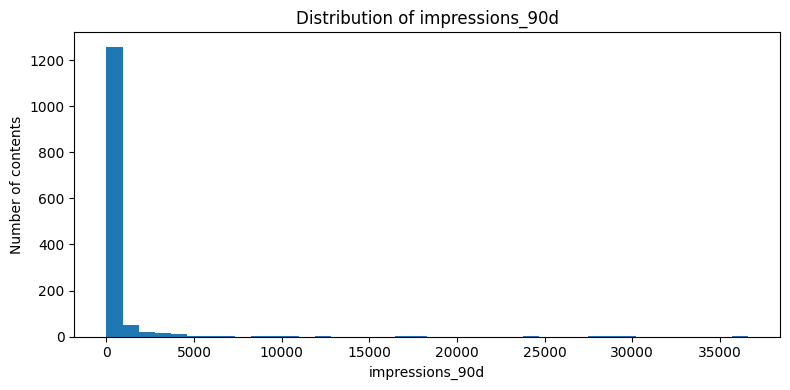

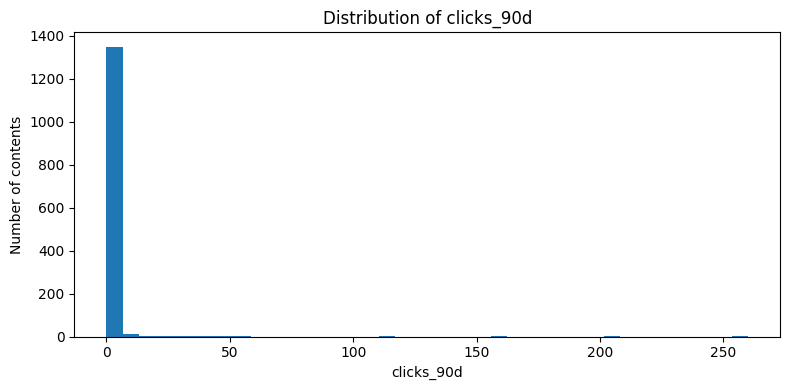

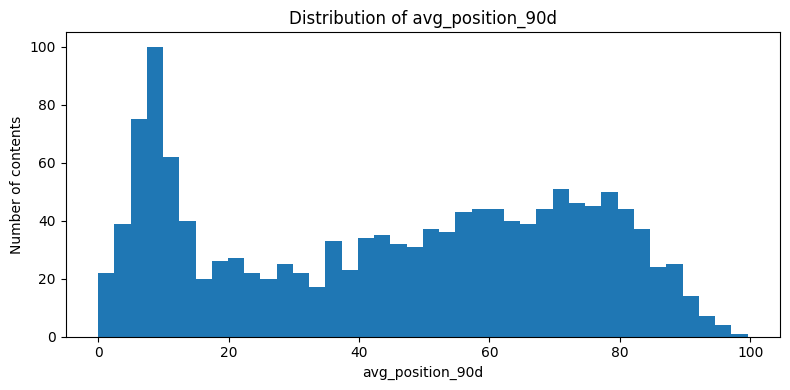

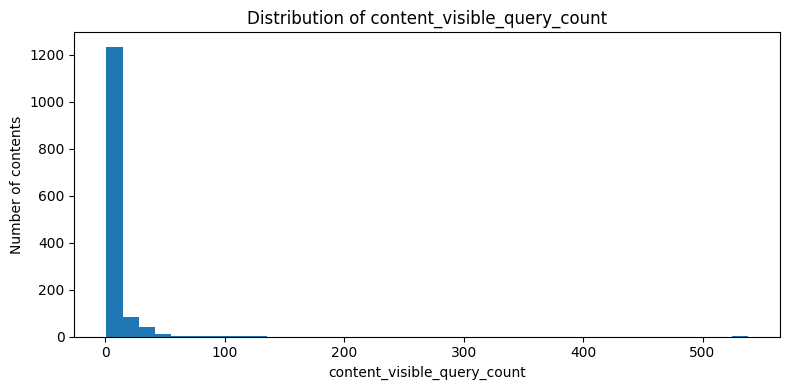

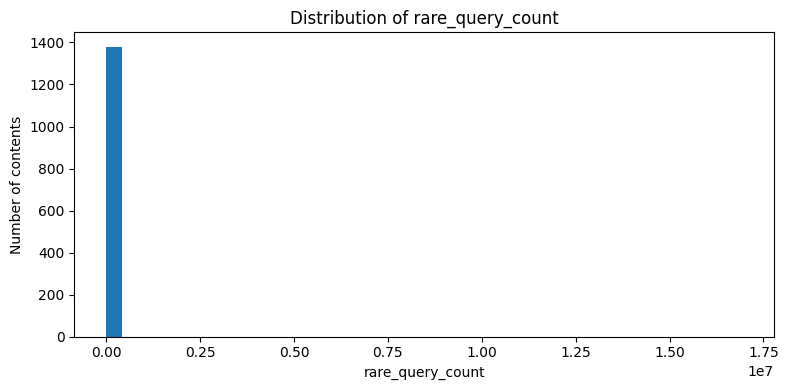

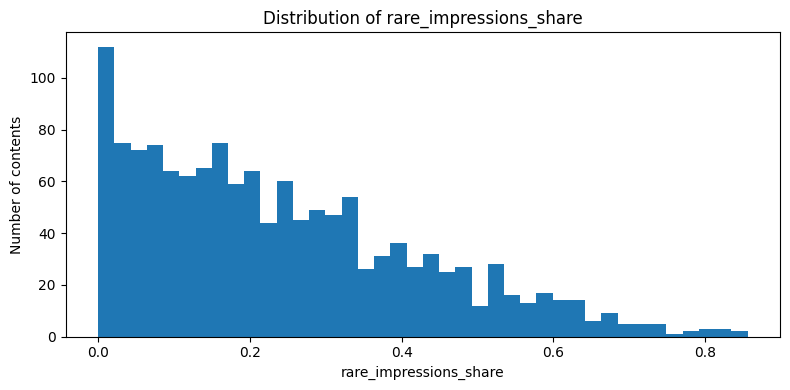

In [55]:
# ============================================================
# EDA 4 — Key performance distributions
# ============================================================

eda_features = [
    "impressions_90d",
    "clicks_90d",
    "avg_position_90d",
    "content_visible_query_count",
    "rare_query_count",
    "rare_impressions_share",
]

for feature in eda_features:
    if feature not in content_df.columns:
        continue

    plt.figure(figsize=(8, 4))

    values = content_df[feature].dropna()

    plt.hist(values, bins=40)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of contents")
    plt.tight_layout()
    plt.show()

# Recent vs previous performance

In [56]:
# ============================================================
# EDA 5 — Recent vs previous 30-day performance
# ============================================================

content_eda = content_df.copy()

# Avoid division by zero
content_eda["impression_change_pct"] = np.where(
    content_eda["impressions_prev30"] > 0,
    (
        (content_eda["impressions_last30"]
         - content_eda["impressions_prev30"])
        / content_eda["impressions_prev30"]
    ) * 100,
    np.nan
)

content_eda["click_change_pct"] = np.where(
    content_eda["clicks_prev30"] > 0,
    (
        (content_eda["clicks_last30"]
         - content_eda["clicks_prev30"])
        / content_eda["clicks_prev30"]
    ) * 100,
    np.nan
)

print("Impression change (%)")
display(
    content_eda["impression_change_pct"]
    .describe()
)

print("\nClick change (%)")
display(
    content_eda["click_change_pct"]
    .describe()
)

Impression change (%)


,impression_change_pct
count,1318.000000
mean,48.139486
std,651.121146
min,-100.000000
25%,-83.333333
50%,-47.605133
75%,11.280242
max,14700.000000



Click change (%)


,click_change_pct
count,107.000000
mean,-71.565757
std,44.321200
min,-100.000000
25%,-100.000000
50%,-100.000000
75%,-50.000000
max,100.000000


# Create the capstone target

In [57]:
# ============================================================
# EDA 6 — Define declining-content proxy label
# ============================================================

content_eda["is_declining"] = (
    content_eda["impression_change_pct"] <= -20
).astype(int)

print("Declining distribution")
print("=" * 60)

print(
    content_eda["is_declining"]
    .value_counts()
)

print("\nDeclining rate:")
print(
    round(
        content_eda["is_declining"].mean(),
        3
    )
)

Declining distribution
is_declining
1    849
0    531
Name: count, dtype: int64

Declining rate:
0.615


# Target distribution

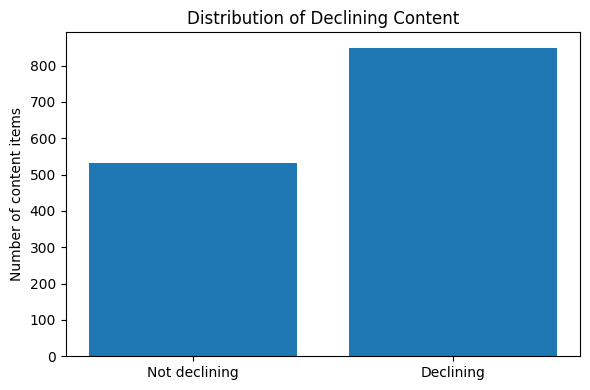

Base rate of declining content: 0.615


In [58]:
# ============================================================
# EDA 7 — Target distribution
# ============================================================

target_counts = (
    content_eda["is_declining"]
    .value_counts()
    .sort_index()
)

labels = [
    "Not declining",
    "Declining"
]

plt.figure(figsize=(6, 4))

plt.bar(
    labels,
    target_counts.values
)

plt.title("Distribution of Declining Content")
plt.ylabel("Number of content items")

plt.tight_layout()
plt.show()

print(
    "Base rate of declining content:",
    round(content_eda["is_declining"].mean(), 3)
)

# Compare declining vs non-declining content

In [59]:
# ============================================================
# EDA 8 — Compare declining vs non-declining content
# ============================================================

comparison_features = [
    "impressions_90d",
    "clicks_90d",
    "impressions_last30",
    "clicks_last30",
    "impressions_prev30",
    "clicks_prev30",
    "avg_position_90d",
    "avg_position_last30",
    "avg_position_prev30",
    "content_visible_query_count",
    "rare_query_count",
    "rare_impressions_share",
]

comparison = (
    content_eda
    .groupby("is_declining")[comparison_features]
    .median()
    .T
)

comparison.columns = [
    "Not declining",
    "Declining"
]

display(comparison)

,Not declining,Declining
impressions_90d,87.000000,75.000000
clicks_90d,0.000000,0.000000
impressions_last30,42.000000,8.000000
clicks_last30,0.000000,0.000000
impressions_prev30,23.000000,34.000000
clicks_prev30,0.000000,0.000000
avg_position_90d,58.997849,40.282978
avg_position_last30,60.118306,45.240184
avg_position_prev30,60.758681,40.818182
content_visible_query_count,3.000000,3.000000


# Position change

is_declining
0    0.287140
1    2.558546
Name: position_change, dtype: float64


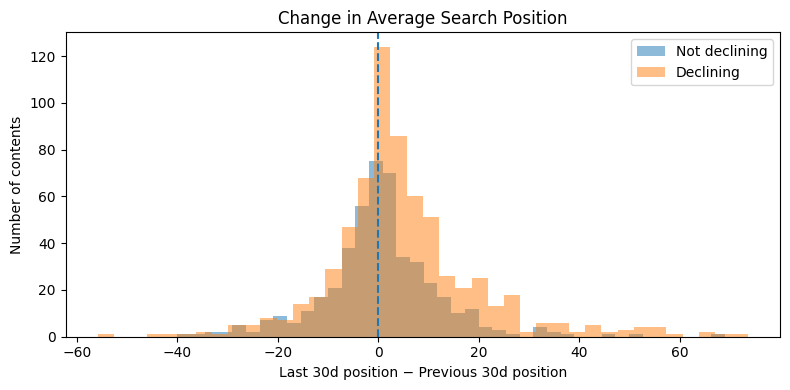

In [60]:
# ============================================================
# EDA 9 — Position change
# ============================================================

content_eda["position_change"] = (
    content_eda["avg_position_last30"]
    - content_eda["avg_position_prev30"]
)

print(
    content_eda.groupby("is_declining")[
        "position_change"
    ].median()
)

plt.figure(figsize=(8, 4))

for label in [0, 1]:
    values = content_eda.loc[
        content_eda["is_declining"] == label,
        "position_change"
    ].dropna()

    plt.hist(
        values,
        bins=40,
        alpha=0.5,
        label=labels[label]
    )

plt.axvline(0, linestyle="--")

plt.title("Change in Average Search Position")
plt.xlabel("Last 30d position − Previous 30d position")
plt.ylabel("Number of contents")
plt.legend()

plt.tight_layout()
plt.show()

# Correlation with the target

In [61]:
# ============================================================
# EDA 10 — Correlation with declining label
# ============================================================

correlation_features = [
    "impressions_90d",
    "clicks_90d",
    "impressions_last30",
    "clicks_last30",
    "impressions_prev30",
    "clicks_prev30",
    "avg_position_90d",
    "avg_position_last30",
    "avg_position_prev30",
    "content_visible_query_count",
    "rare_query_count",
    "rare_impressions_share",
]

corr_df = content_eda[
    correlation_features + ["is_declining"]
].corr(numeric_only=True)

target_corr = (
    corr_df["is_declining"]
    .drop("is_declining")
    .sort_values()
)

display(
    target_corr.to_frame("correlation_with_declining")
)

,correlation_with_declining
avg_position_prev30,-0.249418
avg_position_90d,-0.218199
avg_position_last30,-0.211022
impressions_last30,-0.075460
rare_impressions_share,-0.072174
clicks_last30,-0.037679
rare_query_count,-0.033532
content_visible_query_count,-0.005839
clicks_90d,0.012987
impressions_90d,0.014926


# Final EDA sanity check

In [62]:
# ============================================================
# EDA 14 — Final sanity check
# ============================================================

print("=" * 60)
print("FINAL EDA SANITY CHECK")
print("=" * 60)

print("Rows:", len(content_eda))
print("Columns:", len(content_eda.columns))

print(
    "Unique clients:",
    content_eda["client_hash_id"].nunique()
)

print(
    "Unique contents:",
    content_eda["content_hash_id"].nunique()
)

print(
    "Declining rate:",
    round(
        content_eda["is_declining"].mean(),
        3
    )
)

print("\nTarget counts:")
print(
    content_eda["is_declining"]
    .value_counts()
)

print("\nMissing target:")
print(
    content_eda["is_declining"].isna().sum()
)

FINAL EDA SANITY CHECK
Rows: 1380
Columns: 20
Unique clients: 1
Unique contents: 1380
Declining rate: 0.615

Target counts:
is_declining
1    849
0    531
Name: count, dtype: int64

Missing target:
0


### Data exclusions

The capstone uses the public-safe `fact_content_query_90d` warehouse table as its primary performance source.

The analysis is performed at the client-content level after aggregating query-level observations.

The following fields are deliberately excluded from modeling:

- `client_hash_id` — retained only for grouped validation and aggregation; never used as a predictive feature.
- `content_hash_id` — retained only to identify pages in the ranked output; never used as a predictive feature.
- `query_hash_id` — not used as a predictive feature because it is an identifier.
- `query_char_count` and `query_token_count` — query-level fields are not directly used in the page-level model.
- `window_start` and `window_end` — retained for temporal interpretation but not used as predictive features.
- Any label-derived trend field such as `trend_direction` or `trend_pct` — excluded to prevent leakage.
- Any client-identifying information, domains, URLs, private queries, credentials, or raw exports — excluded from the public analysis.

The dataset contains pseudonymous identifiers rather than client names or domains. These identifiers are used only for grouping, joining, and validation.

### Data used

This study uses the FlyRank internship warehouse, specifically the
`fact_content_query_90d` table.

The source contains anonymized query-level search performance observations
for content pages. Each observation is associated with a pseudonymous client,
content page, and query.

The main performance measures include:

- 90-day impressions and clicks
- Last-30-day impressions and clicks
- Previous-30-day impressions and clicks
- Average search position
- Visible query counts
- Rare-query statistics
- Anonymized impression share

For the modeling task, query-level observations are aggregated to one row per
client-content pair. This matches the decision unit of the capstone: ranking
content pages for potential review.

No client names, domains, URLs, private queries, credentials, or raw
client-identifying information are included in the analysis or final paper.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [39]:
# ============================================================
# METHODOLOGY 1 — Prepare modeling dataframe
# ============================================================

import numpy as np
import pandas as pd

# content_df was created in the Data section.
model_df = content_df.copy()

print("Modeling dataframe shape:", model_df.shape)

print("\nColumns:")
for col in model_df.columns:
    print("-", col)

display(model_df.head())

Modeling dataframe shape: (1380, 16)

Columns:
- client_hash_id
- content_hash_id
- impressions_90d
- clicks_90d
- impressions_last30
- clicks_last30
- impressions_prev30
- clicks_prev30
- avg_position_90d
- avg_position_last30
- avg_position_prev30
- content_total_impressions_90d
- content_visible_query_count
- rare_query_count
- rare_impressions_share
- anonymized_impressions_share


,client_hash_id,content_hash_id,impressions_90d,clicks_90d,impressions_last30,clicks_last30,impressions_prev30,clicks_prev30,avg_position_90d,avg_position_last30,avg_position_prev30,content_total_impressions_90d,content_visible_query_count,rare_query_count,rare_impressions_share,anonymized_impressions_share
0,client_08a6a72ff48e62c0,content_447894f2faf0d2bc,165,0,20,0,27,0,8.802283,15.218182,12.191919,1466,14,224,0.043656,0.725102
1,client_08a6a72ff48e62c0,content_447b93d5ff670356,48,0,2,0,20,0,70.315126,70.000000,71.555556,339,2,64,0.162242,0.696165
2,client_08a6a72ff48e62c0,content_4483e354a2992497,324,0,66,0,90,0,6.660803,12.884620,10.408635,2169,13,533,0.051176,0.799447
3,client_08a6a72ff48e62c0,content_4486e5efcc7b773f,486,1,253,0,152,1,27.304571,27.728319,22.731801,2311,10,420,0.041108,0.748594
4,client_08a6a72ff48e62c0,content_4489a53aa451dca0,76,0,17,0,28,0,13.221021,12.313095,15.472159,304,4,72,0.125000,0.625000


# EDA — understand the distributions

### Exploratory analysis

Before defining the ranking model, the main performance variables are
examined for skew, missingness, and extreme values.

The purpose of this analysis is descriptive rather than causal.

Create target label

In [40]:
# ============================================================
# METHODOLOGY 2 — Define target
# ============================================================

# Calculate percentage change from the previous 30 days
# to the latest 30 days.

model_df["trend_pct"] = np.where(
    model_df["impressions_prev30"] > 0,
    (
        (
            model_df["impressions_last30"]
            - model_df["impressions_prev30"]
        )
        / model_df["impressions_prev30"]
    ) * 100,
    np.nan
)

# Binary target:
# 1 = declining
# 0 = not declining

model_df["is_declining"] = (
    model_df["trend_pct"] < 0
).astype(int)

print("Target distribution:")
print(model_df["is_declining"].value_counts())

print("\nTarget percentage:")
print(
    model_df["is_declining"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target distribution:
is_declining
1    927
0    453
Name: count, dtype: int64

Target percentage:
is_declining
1    67.17
0    32.83
Name: proportion, dtype: float64


# Select features

In [41]:
# ============================================================
# METHODOLOGY 3 — Feature selection
# ============================================================

features = [
    "impressions_prev30",
    "clicks_prev30",
    "avg_position_prev30",
    "impressions_last30",
    "clicks_last30",
    "avg_position_last30",
    "content_total_impressions_90d",
    "content_visible_query_count",
    "rare_query_count",
    "rare_impressions_share",
    "anonymized_impressions_share"
]

print("Selected features:")
for feature in features:
    print("-", feature)

print("\nNumber of features:", len(features))

Selected features:
- impressions_prev30
- clicks_prev30
- avg_position_prev30
- impressions_last30
- clicks_last30
- avg_position_last30
- content_total_impressions_90d
- content_visible_query_count
- rare_query_count
- rare_impressions_share
- anonymized_impressions_share

Number of features: 11


# Create X and y

In [42]:
# ============================================================
# METHODOLOGY 4 — Build feature matrix and target
# ============================================================

X = model_df[features].copy()
y = model_df["is_declining"].copy()

# Convert possible infinite values to NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Convert all modeling columns to numeric
for column in X.columns:
    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )

# Fill missing values using training-independent
# median values calculated from the complete modeling data.
X = X.fillna(X.median())

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values:")
print(X.isna().sum())

print("\nTarget distribution:")
print(y.value_counts())

X shape: (1380, 11)
y shape: (1380,)

Missing values:
impressions_prev30               0
clicks_prev30                    0
avg_position_prev30              0
impressions_last30               0
clicks_last30                    0
avg_position_last30              0
content_total_impressions_90d    0
content_visible_query_count      0
rare_query_count                 0
rare_impressions_share           0
anonymized_impressions_share     0
dtype: int64

Target distribution:
is_declining
1    927
0    453
Name: count, dtype: int64


# Leakage check

In [43]:
# ============================================================
# METHODOLOGY 5 — Leakage check
# ============================================================

forbidden_features = [
    "trend_pct",
    "is_declining",
    "trend_direction",
    "client_hash_id",
    "content_hash_id",
    "query_hash_id"
]

leakage_found = [
    column
    for column in forbidden_features
    if column in X.columns
]

print("Forbidden columns found in X:")
print(leakage_found)

assert len(leakage_found) == 0, (
    "Leakage detected: remove target-derived or identifier columns."
)

print("\n✓ Leakage check passed.")

Forbidden columns found in X:
[]

✓ Leakage check passed.


# Check the client situation

In [44]:
# ============================================================
# METHODOLOGY 6 — Client structure
# ============================================================

unique_clients = model_df["client_hash_id"].nunique()

print("Unique clients:", unique_clients)

if unique_clients == 1:
    print("\nWARNING:")
    print(
        "The available content sample contains only one client."
    )
    print(
        "Client-grouped validation cannot be performed "
        "with this sample."
    )
else:
    print(
        "\nMultiple clients are available."
    )

Unique clients: 1

The available content sample contains only one client.
Client-grouped validation cannot be performed with this sample.


# Train/test split

In [45]:
# ============================================================
# METHODOLOGY 7 — Train/test split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training samples: 1104
Testing samples: 276

Training target distribution:
is_declining
1    0.672
0    0.328
Name: proportion, dtype: float64

Testing target distribution:
is_declining
1    0.67
0    0.33
Name: proportion, dtype: float64


# Create the transparent baseline

In [46]:
# ============================================================
# METHODOLOGY 8 — Transparent baseline
# ============================================================

test_df = model_df.loc[X_test.index].copy()

baseline_score = (
    test_df["impressions_prev30"].fillna(0)
    *
    (
        test_df["impressions_last30"].fillna(0)
        <
        test_df["impressions_prev30"].fillna(0)
    ).astype(int)
)

print("Baseline created.")

print(
    "Baseline score range:",
    baseline_score.min(),
    "to",
    baseline_score.max()
)

Baseline created.
Baseline score range: 0 to 5561


# Precision@K function

In [47]:
# ============================================================
# METHODOLOGY 9 — Ranking metric
# ============================================================

def precision_at_k(scores, labels, k):
    """
    Precision@K:
    proportion of true declining items
    among the top K ranked items.
    """

    scores = np.asarray(scores)
    labels = np.asarray(labels)

    order = np.argsort(-scores)

    top_k_labels = labels[order[:k]]

    return top_k_labels.mean()


for k in [20, 50]:

    if len(y_test) >= k:

        score = precision_at_k(
            baseline_score,
            y_test,
            k
        )

        print(
            f"Baseline Precision@{k}: "
            f"{score:.3f}"
        )

Baseline Precision@20: 1.000
Baseline Precision@50: 1.000


# Train the model

In [48]:
# ============================================================
# METHODOLOGY 10 — Train decision tree
# ============================================================

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=3,
    class_weight="balanced",
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

print("Decision tree trained successfully.")

print("Tree depth:", tree_model.get_depth())
print("Number of leaves:", tree_model.get_n_leaves())

Decision tree trained successfully.
Tree depth: 3
Number of leaves: 8


# Inspect the learned rules

In [49]:
# ============================================================
# METHODOLOGY 11 — Interpret the tree
# ============================================================

from sklearn.tree import export_text

tree_rules = export_text(
    tree_model,
    feature_names=features
)

print(tree_rules)

|--- avg_position_prev30 <= 45.26
|   |--- impressions_last30 <= 12.50
|   |   |--- impressions_prev30 <= 6.50
|   |   |   |--- class: 1
|   |   |--- impressions_prev30 >  6.50
|   |   |   |--- class: 1
|   |--- impressions_last30 >  12.50
|   |   |--- impressions_prev30 <= 21.50
|   |   |   |--- class: 0
|   |   |--- impressions_prev30 >  21.50
|   |   |   |--- class: 1
|--- avg_position_prev30 >  45.26
|   |--- impressions_last30 <= 8.50
|   |   |--- impressions_prev30 <= 5.50
|   |   |   |--- class: 0
|   |   |--- impressions_prev30 >  5.50
|   |   |   |--- class: 1
|   |--- impressions_last30 >  8.50
|   |   |--- impressions_prev30 <= 19.50
|   |   |   |--- class: 0
|   |   |--- impressions_prev30 >  19.50
|   |   |   |--- class: 0



# Generate predictions

In [50]:
# ============================================================
# METHODOLOGY 12 — Generate model ranking
# ============================================================

model_scores = tree_model.predict_proba(
    X_test
)[:, 1]

print("Model scores generated.")

print(
    "Score range:",
    round(model_scores.min(), 3),
    "to",
    round(model_scores.max(), 3)
)

Model scores generated.
Score range: 0.023 to 1.0


# Evaluate model vs baseline

In [51]:
# ============================================================
# METHODOLOGY 13 — Model vs baseline
# ============================================================

results = []

for k in [20, 50]:

    baseline_precision = precision_at_k(
        baseline_score,
        y_test,
        k
    )

    model_precision = precision_at_k(
        model_scores,
        y_test,
        k
    )

    results.append({
        "K": k,
        "Baseline Precision@K": round(
            baseline_precision,
            3
        ),
        "Decision Tree Precision@K": round(
            model_precision,
            3
        )
    })

results_df = pd.DataFrame(results)

display(results_df)

,K,Baseline Precision@K,Decision Tree Precision@K
0,20,1.0,1.0
1,50,1.0,1.0


# Calculate the base rate

In [52]:
# ============================================================
# METHODOLOGY 14 — Base rate
# ============================================================

base_rate = y_test.mean()

print(
    f"Test-set declining base rate: "
    f"{base_rate:.3f}"
)

print(
    f"Percentage of declining content: "
    f"{base_rate * 100:.1f}%"
)

Test-set declining base rate: 0.670
Percentage of declining content: 67.0%


# Feature importance

In [53]:
# ============================================================
# METHODOLOGY 15 — Feature importance
# ============================================================

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": tree_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(feature_importance)

,feature,importance
0,impressions_prev30,0.477387
1,impressions_last30,0.271091
2,avg_position_prev30,0.251522
3,clicks_prev30,0.000000
4,clicks_last30,0.000000
5,avg_position_last30,0.000000
6,content_total_impressions_90d,0.000000
7,content_visible_query_count,0.000000
8,rare_query_count,0.000000
9,rare_impressions_share,0.000000


### Methodology summary

The unit of analysis is a content item. The target identifies whether the item's impressions declined between the previous 30-day period and the latest 30-day period.

The target is defined as:

`is_declining = 1` when `impressions_last30 < impressions_prev30`.

The model uses observable performance and content-level signals, including previous-period impressions and clicks, average search position, content exposure, query visibility, rare-query metrics, and anonymized impression share.

Target-derived variables such as `trend_pct` and `is_declining` are excluded from the feature matrix to prevent leakage. Client and content identifiers are also excluded from modeling features.

A transparent ranking rule is used as the baseline. The main model is a depth-3 decision tree because its learned rules can be inspected and explained to a human reviewer.

The available content sample contains 1,380 rows but only one client. Therefore, client-grouped validation is not possible with this sample. The experiment instead uses an 80/20 stratified train/test split with `random_state=42`.

The primary evaluation metrics are Precision@20 and Precision@50. The declining base rate is reported alongside these metrics to provide context.

This experiment is therefore treated as a single-client proof of concept rather than evidence of generalization across FlyRank clients.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Model vs baseline

The baseline and decision tree are evaluated on exactly the same held-out test set.

The declining base rate is reported alongside Precision@K to provide context for interpreting the ranking performance.

In [35]:
# ============================================================
# RESULTS — Model vs baseline
# ============================================================

display(results_df)

print(f"Test-set declining base rate: {base_rate:.3f}")

,k,baseline_precision,model_precision
0,20,1.0,1.0
1,50,1.0,1.0


Test-set declining base rate: 0.670


In [64]:
# ============================================================
# RESULTS — Error analysis
# ============================================================

error_analysis = X_test.copy()

error_analysis["actual"] = y_test.values
error_analysis["model_score"] = model_scores
error_analysis["predicted"] = (
    model_scores >= 0.5
).astype(int)

error_analysis["error_type"] = "Correct"

error_analysis.loc[
    (error_analysis["actual"] == 1) &
    (error_analysis["predicted"] == 0),
    "error_type"
] = "False Negative"

error_analysis.loc[
    (error_analysis["actual"] == 0) &
    (error_analysis["predicted"] == 1),
    "error_type"
] = "False Positive"

print("Error distribution")
print("=" * 60)

display(
    error_analysis["error_type"]
    .value_counts()
    .to_frame("count")
)

Error distribution


,count
error_type,
Correct,212
False Negative,46
False Positive,18


In [65]:
# Compare model scores by error type

error_summary = (
    error_analysis
    .groupby("error_type")["model_score"]
    .agg(
        count="count",
        mean_score="mean"
    )
    .sort_values("mean_score", ascending=False)
)

display(error_summary)

,count,mean_score
error_type,,
False Positive,18,0.681525
Correct,212,0.634511
False Negative,46,0.300556


## 5. Limitations

*What this work cannot claim.*


- The current modeling sample contains only one client, so client-level holdout validation could not be performed.
- The train/test split is therefore stratified at the content-row level rather than grouped by client.
- The target is a proxy based on changes in impressions; it does not represent the cause of the decline.
- Precision@K measures ranking usefulness but does not establish that the model causes better SEO outcomes.
- The model should be treated as decision support for prioritization, not as a prediction of Google's ranking algorithm.
- The available anonymized data does not allow client-specific recommendations.
- Results should be revalidated on a multi-client holdout before deployment.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [66]:
# ============================================================
# RANKED RECOMMENDATIONS
# ============================================================

recommendations = model_df.loc[X_test.index].copy()

recommendations["model_score"] = model_scores

# Higher score = higher priority for review
recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
)

# Add observed change for easier interpretation
if {
    "impressions_prev30",
    "impressions_last30"
}.issubset(recommendations.columns):

    recommendations["impression_change_pct"] = np.where(
        recommendations["impressions_prev30"] > 0,
        (
            (
                recommendations["impressions_last30"]
                - recommendations["impressions_prev30"]
            )
            / recommendations["impressions_prev30"]
        ) * 100,
        np.nan
    )

# Simple decision-support action
recommendations["recommended_action"] = (
    "Review content performance"
)

recommendation_columns = [
    "content_hash_id",
    "model_score",
    "impression_change_pct",
    "impressions_prev30",
    "impressions_last30",
    "clicks_prev30",
    "clicks_last30",
    "avg_position_prev30",
    "avg_position_last30",
    "recommended_action"
]

recommendation_columns = [
    col
    for col in recommendation_columns
    if col in recommendations.columns
]

top_recommendations = recommendations[
    recommendation_columns
].head(20)

display(top_recommendations)

,content_hash_id,model_score,impression_change_pct,impressions_prev30,impressions_last30,clicks_prev30,clicks_last30,avg_position_prev30,avg_position_last30,recommended_action
144,content_47312d556dd8e54f,1.0,-100.000000,22,0,0,0,10.000000,NaN,Review content performance
549,content_4ef177377a1f503a,1.0,-100.000000,33,0,0,0,42.969697,NaN,Review content performance
1006,content_586c95ccbd8c0874,1.0,-86.585366,82,11,0,0,21.061729,13.305556,Review content performance
1118,content_5aa4d9a080cb01b2,1.0,-71.428571,7,2,0,0,27.714286,41.500000,Review content performance
853,content_5558cde4dbc3830d,1.0,-100.000000,8,0,0,0,7.625000,NaN,Review content performance
901,content_565cb6b19ff18fd9,1.0,-100.000000,11,0,0,0,3.090909,NaN,Review content performance
56,content_4592b5b45896187a,1.0,-60.000000,10,4,0,0,8.300000,9.500000,Review content performance
1131,content_5aeb5db4883022b6,1.0,-86.075949,79,11,0,0,8.473647,12.722222,Review content performance
100,content_467167cc22c7c7a4,1.0,-100.000000,11,0,0,0,12.272727,NaN,Review content performance
52,content_4583190711ac34b5,1.0,-93.846154,65,4,0,0,25.589286,67.500000,Review content performance


### How the ranked output should be used

The model output is a prioritization queue rather than an automatic decision.

A FlyRank editor could start with the highest-ranked content items, inspect the underlying performance changes, and decide whether the page deserves a content refresh or further investigation.

The ranking should not be interpreted as evidence that refreshing a page will cause its performance to improve. It only identifies content items whose observed signals make them higher-priority candidates for review.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

# Artifact 1 — Feature importance

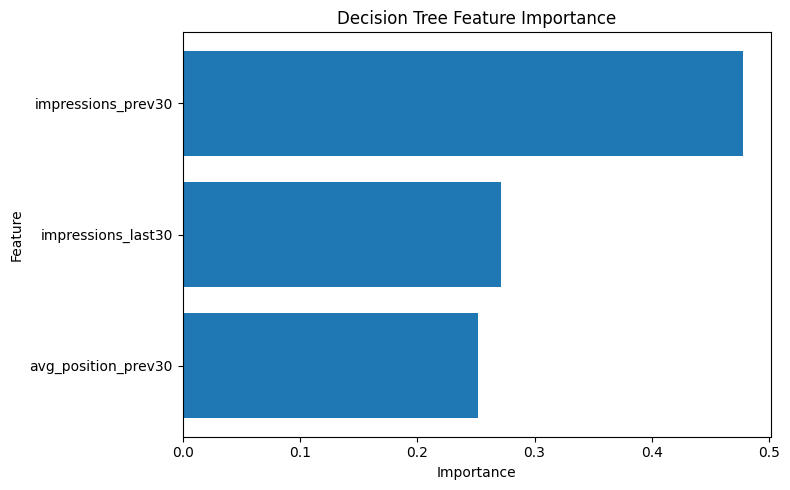

In [67]:
# ============================================================
# ARTIFACT 1 — Feature importance
# ============================================================

plot_df = feature_importance[
    feature_importance["importance"] > 0
].copy()

if len(plot_df) > 0:

    plot_df = plot_df.sort_values("importance")

    plt.figure(figsize=(8, 5))

    plt.barh(
        plot_df["feature"],
        plot_df["importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Decision Tree Feature Importance")

    plt.tight_layout()
    plt.show()

else:
    print("No non-zero feature importances were found.")

# Artifact 2 — Model vs baseline

In [68]:
# ============================================================
# ARTIFACT 2 — Model vs baseline
# ============================================================

metrics_to_plot = results_df.copy()

print("Model vs baseline")
display(metrics_to_plot)

Model vs baseline


,K,Baseline Precision@K,Decision Tree Precision@K
0,20,1.0,1.0
1,50,1.0,1.0


# Artifact 3 — Declining vs non-declining

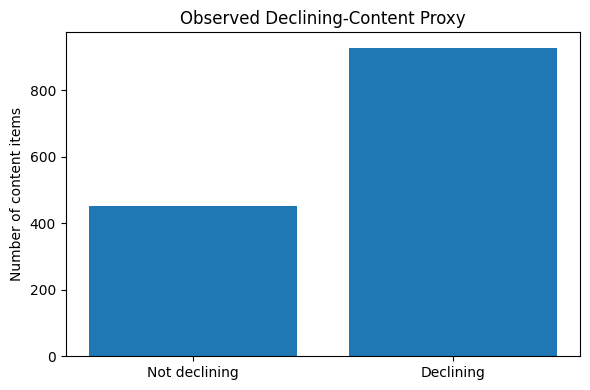

In [69]:
# ============================================================
# ARTIFACT 3 — Target distribution
# ============================================================

target_counts = (
    y.value_counts()
    .sort_index()
)

plt.figure(figsize=(6, 4))

plt.bar(
    ["Not declining", "Declining"],
    target_counts.values
)

plt.title("Observed Declining-Content Proxy")
plt.ylabel("Number of content items")

plt.tight_layout()
plt.show()

## Reproducibility

The capstone was developed in Google Colab using Python and scikit-learn.

The modeling pipeline uses `random_state=42` for reproducible train/test splitting and decision-tree training.

To reproduce the analysis:

1. Open `work/notebooks/capstone.ipynb`.
2. Run the notebook from top to bottom using **Runtime → Run all**.
3. Ensure the required Python packages are installed.
4. Confirm that the final results, recommendations, and artifacts are generated without errors.
5. The completed notebook is committed to the repository under `work/notebooks/`.

In [70]:
# ============================================================
# FINAL CAPSTONE RESULTS — COPY THESE INTO THE PAPER
# ============================================================

print("=" * 60)
print("FINAL CAPSTONE RESULTS")
print("=" * 60)

print("\n1. DATASET")
print("-" * 60)
print("Modeling rows:", len(model_df))
print("Features:", X.shape[1])
print("Positive cases:", int(y.sum()))
print("Negative cases:", int((y == 0).sum()))
print("Base rate:", round(y.mean(), 4))

print("\n2. SPLIT")
print("-" * 60)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\n3. MODEL VS BASELINE")
print("-" * 60)
display(results_df)

print("\n4. FEATURE IMPORTANCE")
print("-" * 60)
display(feature_importance)

print("\n5. TOP RECOMMENDATIONS")
print("-" * 60)
display(top_recommendations.head(20))

FINAL CAPSTONE RESULTS

1. DATASET
------------------------------------------------------------
Modeling rows: 1380
Features: 11
Positive cases: 927
Negative cases: 453
Base rate: 0.6717

2. SPLIT
------------------------------------------------------------
Training rows: 1104
Test rows: 276

3. MODEL VS BASELINE
------------------------------------------------------------


,K,Baseline Precision@K,Decision Tree Precision@K
0,20,1.0,1.0
1,50,1.0,1.0



4. FEATURE IMPORTANCE
------------------------------------------------------------


,feature,importance
0,impressions_prev30,0.477387
1,impressions_last30,0.271091
2,avg_position_prev30,0.251522
3,clicks_prev30,0.000000
4,clicks_last30,0.000000
5,avg_position_last30,0.000000
6,content_total_impressions_90d,0.000000
7,content_visible_query_count,0.000000
8,rare_query_count,0.000000
9,rare_impressions_share,0.000000



5. TOP RECOMMENDATIONS
------------------------------------------------------------


,content_hash_id,model_score,impression_change_pct,impressions_prev30,impressions_last30,clicks_prev30,clicks_last30,avg_position_prev30,avg_position_last30,recommended_action
144,content_47312d556dd8e54f,1.0,-100.000000,22,0,0,0,10.000000,NaN,Review content performance
549,content_4ef177377a1f503a,1.0,-100.000000,33,0,0,0,42.969697,NaN,Review content performance
1006,content_586c95ccbd8c0874,1.0,-86.585366,82,11,0,0,21.061729,13.305556,Review content performance
1118,content_5aa4d9a080cb01b2,1.0,-71.428571,7,2,0,0,27.714286,41.500000,Review content performance
853,content_5558cde4dbc3830d,1.0,-100.000000,8,0,0,0,7.625000,NaN,Review content performance
901,content_565cb6b19ff18fd9,1.0,-100.000000,11,0,0,0,3.090909,NaN,Review content performance
56,content_4592b5b45896187a,1.0,-60.000000,10,4,0,0,8.300000,9.500000,Review content performance
1131,content_5aeb5db4883022b6,1.0,-86.075949,79,11,0,0,8.473647,12.722222,Review content performance
100,content_467167cc22c7c7a4,1.0,-100.000000,11,0,0,0,12.272727,NaN,Review content performance
52,content_4583190711ac34b5,1.0,-93.846154,65,4,0,0,25.589286,67.500000,Review content performance


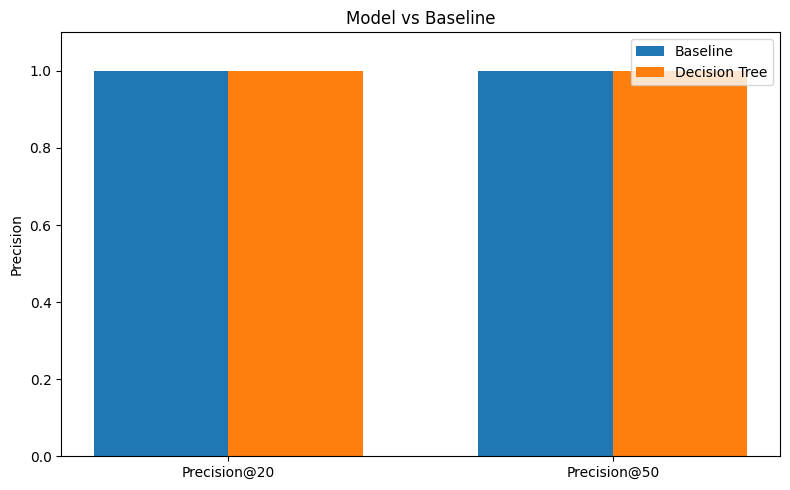

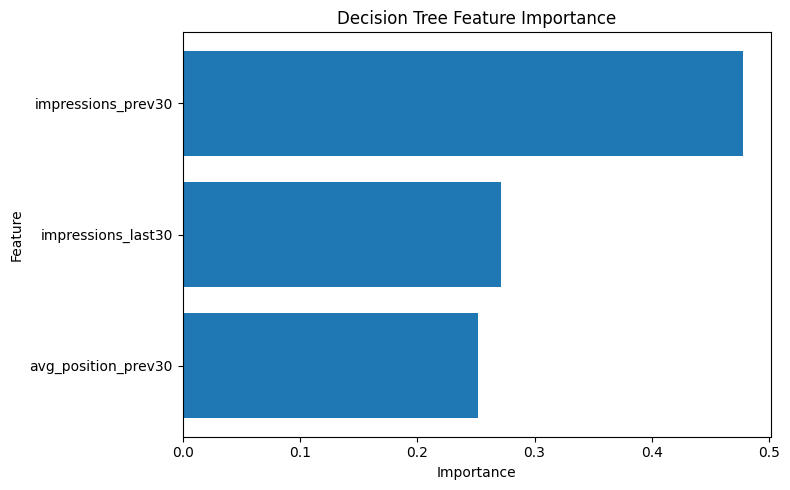

Paper artifacts generated:
paper/assets/results_comparison.png
paper/assets/feature_importance.png


In [71]:
# ============================================================
# PAPER ARTIFACTS — Generate publication-ready charts
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

# Create output directory
artifact_dir = Path("paper/assets")
artifact_dir.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. MODEL VS BASELINE
# ------------------------------------------------------------

metrics = ["Precision@20", "Precision@50"]

baseline_values = [
    results_df.loc[results_df["K"] == 20, "Baseline Precision@K"].iloc[0],
    results_df.loc[results_df["K"] == 50, "Baseline Precision@K"].iloc[0],
]

model_values = [
    results_df.loc[results_df["K"] == 20, "Decision Tree Precision@K"].iloc[0],
    results_df.loc[results_df["K"] == 50, "Decision Tree Precision@K"].iloc[0],
]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    [i - width / 2 for i in x],
    baseline_values,
    width=width,
    label="Baseline"
)

plt.bar(
    [i + width / 2 for i in x],
    model_values,
    width=width,
    label="Decision Tree"
)

plt.xticks(list(x), metrics)
plt.ylabel("Precision")
plt.ylim(0, 1.1)
plt.title("Model vs Baseline")
plt.legend()

plt.tight_layout()

plt.savefig(
    artifact_dir / "results_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 2. FEATURE IMPORTANCE
# ------------------------------------------------------------

plot_df = feature_importance[
    feature_importance["importance"] > 0
].copy()

plot_df = plot_df.sort_values("importance")

plt.figure(figsize=(8, 5))

plt.barh(
    plot_df["feature"],
    plot_df["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")

plt.tight_layout()

plt.savefig(
    artifact_dir / "feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("Paper artifacts generated:")
print(artifact_dir / "results_comparison.png")
print(artifact_dir / "feature_importance.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.